In [1]:
import matplotlib.pyplot as plt
import numpy as np
#from netCDF4 import Dataset
from matplotlib import cm
import xarray as xr
import pandas as pd
#import datetime
from xgrads import CtlDescriptor, open_CtlDataset, open_mfdataset
from shapely import wkt, plotting, Point, buffer, geometry, get_coordinates
import netCDF4
import os
import cmweather
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 17
import sys
from scipy import interpolate
import time
import glob
import seaborn as sns
from scipy.stats import linregress

In [2]:
d = {}
d_full = {}
d_full2 = {}
d2 = {}

path = '/data/keeling/a/melinda3/gpm/data_dir/'


li = 6
ui = 29
print(li)
hash = 'final_tracking_algo_hodo_test_'+str(li)+'_'+str(ui)+'_1m_lss_full.csv'
file_in = pd.read_csv(path+hash)
file_in = file_in.replace(-9999, np.nan)
d_full["area{0}_{1}_lss".format(li, ui)] = file_in

hash = 'final_tracking_algo_hodo_test_'+str(li)+'_'+str(ui)+'_1m_dss_full.csv'
file_in = pd.read_csv(path+hash)
file_in = file_in.replace(-9999, np.nan)
d_full["area{0}_{1}_dss".format(li, ui)] = file_in

hash = 'final_tracking_algo_hodo_test_'+str(li)+'_'+str(ui)+'_1m_hss15_full.csv'
file_in = pd.read_csv(path+hash)
file_in = file_in.replace(-9999, np.nan)
d_full["area{0}_{1}_h15".format(li, ui)] = file_in

hash = 'final_tracking_algo_hodo_test_'+str(li)+'_'+str(ui)+'_1m_lss15_full.csv'
file_in = pd.read_csv(path+hash)
file_in = file_in.replace(-9999, np.nan)
d_full["area{0}_{1}_l15".format(li, ui)] = file_in

hash = 'final_tracking_algo_hodo_test_'+str(li)+'_'+str(ui)+'_1m_hss_full.csv'
file_in = pd.read_csv(path+hash)
file_in = file_in.replace(-9999, np.nan)
d_full["area{0}_{1}_hss".format(li, ui)] = file_in

li = 8
print(li)
hash = 'final_tracking_algo_hodo_test_'+str(li)+'_'+str(ui)+'_1m_lss_full.csv'
file_in = pd.read_csv(path+hash)
file_in = file_in.replace(-9999, np.nan)
d_full["area{0}_{1}_lss".format(li, ui)] = file_in

hash = 'final_tracking_algo_hodo_test_'+str(li)+'_'+str(ui)+'_1m_dss_full.csv'
file_in = pd.read_csv(path+hash)
file_in = file_in.replace(-9999, np.nan)
d_full["area{0}_{1}_dss".format(li, ui)] = file_in

hash = 'final_tracking_algo_hodo_test_'+str(li)+'_'+str(ui)+'_1m_hss_full.csv'
file_in = pd.read_csv(path+hash)
file_in = file_in.replace(-9999, np.nan)
d_full["area{0}_{1}_hss".format(li, ui)] = file_in

hash = 'final_tracking_algo_hodo_test_'+str(li)+'_'+str(ui)+'_1m_lss15_full.csv'
file_in = pd.read_csv(path+hash)
file_in = file_in.replace(-9999, np.nan)
d_full["area{0}_{1}_l15".format(li, ui)] = file_in


li = 10
print(li)
hash = 'final_tracking_algo_hodo_test_'+str(li)+'_'+str(ui)+'_1m_hss15_full.csv'
file_in = pd.read_csv(path+hash)
file_in = file_in.replace(-9999, np.nan)
d_full["area{0}_{1}_h15".format(li, ui)] = file_in
hash = 'final_tracking_algo_hodo_test_'+str(li)+'_'+str(ui)+'_1m_lss_full.csv'
file_in = pd.read_csv(path+hash)
file_in = file_in.replace(-9999, np.nan)
d_full["area{0}_{1}_lss".format(li, ui)] = file_in
hash = 'final_tracking_algo_hodo_test_'+str(li)+'_'+str(ui)+'_1m_dss_full.csv'
file_in = pd.read_csv(path+hash)
file_in = file_in.replace(-9999, np.nan)
d_full["area{0}_{1}_dss".format(li, ui)] = file_in
hash = 'final_tracking_algo_hodo_test_'+str(li)+'_'+str(ui)+'_1m_lss15_full.csv'
file_in = pd.read_csv(path+hash)
file_in = file_in.replace(-9999, np.nan)
d_full["area{0}_{1}_l15".format(li, ui)] = file_in


lower_shear = [6, 8, 10]
upper_shear = [31, 33, 35]

for li in lower_shear:
    for ui in upper_shear:
        hash = 'final_tracking_algo_hodo_test_'+str(li)+'_'+str(ui)+'_1m_dss_full.csv'
        file_in = pd.read_csv(path+hash)
        file_in = file_in.replace(-9999, np.nan)
        d_full["area{0}_{1}_dss".format(li, ui)] = file_in
        
        hash = 'final_tracking_algo_hodo_test_'+str(li)+'_'+str(ui)+'_1m_lss_full.csv'
        file_in = pd.read_csv(path+hash)
        file_in = file_in.replace(-9999, np.nan)
        d_full["area{0}_{1}_lss".format(li, ui)] = file_in

        hash = 'final_tracking_algo_hodo_test_'+str(li)+'_'+str(ui)+'_1m_hss_full.csv'
        file_in = pd.read_csv(path+hash)
        file_in = file_in.replace(-9999, np.nan)
        d_full["area{0}_{1}_hss".format(li, ui)] = file_in

        hash = 'final_tracking_algo_hodo_test_'+str(li)+'_'+str(ui)+'_1m_lss15_full.csv'
        file_in = pd.read_csv(path+hash)
        file_in = file_in.replace(-9999, np.nan)
        d_full["area{0}_{1}_l15".format(li, ui)] = file_in

        hash = 'final_tracking_algo_hodo_test_'+str(li)+'_'+str(ui)+'_1m_hss15_full.csv'
        file_in = pd.read_csv(path+hash)
        file_in = file_in.replace(-9999, np.nan)
        d_full["area{0}_{1}_h15".format(li, ui)] = file_in


d2 = d_full

6
8
10


In [3]:
d3 = {}
d_final = {}
path = '/data/keeling/a/melinda3/meso/pres_perts_dir/'
lower_shear = [6, 8, 10]
upper_shear = [31, 33, 35]

for li in lower_shear:
    for ui in upper_shear:
        hash1 = 'press_perts_saved_dss_'+str(li)+str(ui)+'_avg_with_uh.cs'
        hash2 = 'press_perts_saved_dss_'+str(li)+str(ui)+'_all.csv'
        hash_out = 'press_perts_saved_dss_'+str(li)+str(ui)+'_all.csv'
        file_in = pd.read_csv(path+hash2)
        file_comb = pd.read_csv(path+hash1)
        file_in = file_in.replace(-9999, np.nan)
        new_pd = pd.merge(file_in, file_comb, on = 'Unnamed: 0')
        new_pd.to_csv(path+hash_out)
        



FileNotFoundError: [Errno 2] No such file or directory: '/data/keeling/a/melinda3/meso/pres_perts_dir/press_perts_saved_dss_631_avg_with_uh.cs'

In [4]:
#Process the data to get OTD at every time for the runs of interest
a631 = d2['area6_31_dss']
otd_631 = a631.groupby("time", dropna = True).max('z')['z']
a633 = d2['area6_33_dss']
otd_633 = a633.groupby("time", dropna = True).max('z')['z']
a635 = d2['area6_35_dss']
otd_635 = a635.groupby("time", dropna = True).max('z')['z']

a831 = d2['area8_31_dss']
otd_831 = a831.groupby("time", dropna = True).max('z')['z']
a833 = d2['area8_33_dss']
otd_833 = a833.groupby("time", dropna = True).max('z')['z']
a835 = d2['area8_35_dss']
otd_835 = a835.groupby("time", dropna = True).max('z')['z']

a1031 = d2['area10_31_dss']
otd_1031 = a1031.groupby("time", dropna = True).max('z')['z']
a1033 = d2['area10_33_dss']
otd_1033 = a1033.groupby("time", dropna = True).max('z')['z']
a1035 = d2['area10_35_dss']
otd_1035 = a1035.groupby("time", dropna = True).max('z')['z']


In [5]:
tpp_833 = pd.read_csv('/data/keeling/a/melinda3/meso/pres_perts_dir/press_perts_saved_dss_833_all.csv')
tpp_1031 = pd.read_csv('/data/keeling/a/melinda3/meso/pres_perts_dir/press_perts_saved_dss_1031_all.csv')
tpp_631 = pd.read_csv('/data/keeling/a/melinda3/meso/pres_perts_dir/press_perts_saved_dss_631_all.csv')
tpp_1033 = pd.read_csv('/data/keeling/a/melinda3/meso/pres_perts_dir/press_perts_saved_dss_1033_all.csv') 
tpp_633 = pd.read_csv('/data/keeling/a/melinda3/meso/pres_perts_dir/press_perts_saved_dss_633_all.csv')
tpp_635 = pd.read_csv('/data/keeling/a/melinda3/meso/pres_perts_dir/press_perts_saved_dss_635_all.csv')
tpp_1035 = pd.read_csv('/data/keeling/a/melinda3/meso/pres_perts_dir/press_perts_saved_dss_1035_all.csv')
tpp_831 = pd.read_csv('/data/keeling/a/melinda3/meso/pres_perts_dir/press_perts_saved_dss_831_all.csv')
tpp_835 = pd.read_csv('/data/keeling/a/melinda3/meso/pres_perts_dir/press_perts_saved_dss_835_all.csv')


In [6]:
tpp_631 = tpp_631.drop(['time', 'hght', 'time_y', 'hght_y'], axis=1)
tpp_633 = tpp_633.drop(['time', 'hght', 'time_y', 'hght_y'], axis=1)
tpp_635 = tpp_635.drop(['time', 'hght', 'time_y', 'hght_y'], axis=1)
tpp_831 = tpp_831.drop(['time', 'hght', 'time_y', 'hght_y'], axis=1)
tpp_833 = tpp_833.drop(['time', 'hght', 'time_y', 'hght_y'], axis=1)
tpp_835 = tpp_835.drop(['time', 'hght', 'time_y', 'hght_y'], axis=1)
tpp_1031 = tpp_1031.drop(['time', 'hght', 'time_y', 'hght_y'], axis=1)
tpp_1033 = tpp_1033.drop(['time', 'hght', 'time_y', 'hght_y'], axis=1)
tpp_1035 = tpp_1035.drop(['time', 'hght', 'time_y', 'hght_y'], axis=1)

In [7]:
no_dupes_1031 = tpp_1031.drop_duplicates(subset = ['time_x', 'hght_x'], keep = 'first')
no_dupes_631 = tpp_631.drop_duplicates(subset = ['time_x', 'hght_x'],keep = 'first')
no_dupes_1033 = tpp_1033.drop_duplicates(subset = ['time_x', 'hght_x'],keep = 'first')
no_dupes_633 = tpp_633.drop_duplicates(subset = ['time_x', 'hght_x'],keep = 'first')
no_dupes_1035 = tpp_1035.drop_duplicates(subset = ['time_x', 'hght_x'],keep = 'first')
no_dupes_635 = tpp_635.drop_duplicates(subset = ['time_x', 'hght_x'],keep = 'first')
no_dupes_831 = tpp_831.drop_duplicates(subset = ['time_x', 'hght_x'],keep = 'first') 
no_dupes_835 = tpp_835.drop_duplicates(subset = ['time_x', 'hght_x'],keep = 'first')
no_dupes_833 = tpp_833.drop_duplicates(subset = ['time_x', 'hght_x'], keep = 'first') 

In [23]:
tracked_sub631 = no_dupes_631[['time_x', 'hght_x', 'corr_coef', 'corr_coef']]
t5_sub_reind = tracked_sub631.set_index(['time_x', 'hght_x'])
t5_sun_rein2 = t5_sub_reind.dropna()
xr_hel631 = t5_sun_rein2.to_xarray()

ValueError: cannot convert DataFrame with non-unique columns

In [24]:
tracked_sub631

,time_x,hght_x,corr_coef,corr_coef
326,68.0,4.125000,0.995348,0.995348
327,68.0,4.375000,0.988719,0.988719
328,68.0,4.625000,0.970602,0.970602
329,68.0,4.875000,0.926287,0.926287
330,68.0,5.125000,0.885056,0.885056
...,...,...,...,...
1904,99.0,15.125001,0.247027,0.247027
1905,99.0,15.375001,0.324144,0.324144
1906,99.0,15.625001,0.648202,0.648202
1907,99.0,15.875001,0.810712,0.810712


In [ ]:
no_dupes_631['net_acc'] = no_dupes_631['zvavg_over_polygon'] + no_dupes_631['zvavg_over_polygon']
no_dupes_633['net_acc'] = no_dupes_633['zvavg_over_polygon'] + no_dupes_633['zvavg_over_polygon']
no_dupes_635['net_acc'] = no_dupes_635['zvavg_over_polygon'] + no_dupes_635['zvavg_over_polygon']

no_dupes_831['net_acc'] = no_dupes_831['zvavg_over_polygon'] + no_dupes_831['zvavg_over_polygon']
no_dupes_833['net_acc'] = no_dupes_833['zvavg_over_polygon'] + no_dupes_833['zvavg_over_polygon']
no_dupes_835['net_acc'] = no_dupes_835['zvavg_over_polygon'] + no_dupes_835['zvavg_over_polygon']

no_dupes_1031['net_acc'] = no_dupes_1031['zvavg_over_polygon'] + no_dupes_1031['zvavg_over_polygon']
no_dupes_1033['net_acc'] = no_dupes_1033['zvavg_over_polygon'] + no_dupes_1033['zvavg_over_polygon']
no_dupes_1035['net_acc'] = no_dupes_1035['zvavg_over_polygon'] + no_dupes_1035['zvavg_over_polygon']

/tmp/ipykernel_939173/709873181.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  no_dupes_631['net_acc'] = no_dupes_631['dnlpvpgaavg_over_polygon'] + no_dupes_631['dnlpvpgaavg_over_polygon']
/tmp/ipykernel_939173/709873181.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  no_dupes_633['net_acc'] = no_dupes_633['dnlpvpgaavg_over_polygon'] + no_dupes_633['dnlpvpgaavg_over_polygon']
/tmp/ipykernel_939173/709873181.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataF

In [13]:
no_dupes_631 = no_dupes_631[no_dupes_631.time_x > a631['time_split'].iloc[0]]
no_dupes_633 = no_dupes_633[no_dupes_633.time_x > a633['time_split'].iloc[0]]
no_dupes_635 = no_dupes_635[no_dupes_635.time_x > a635['time_split'].iloc[0]]

no_dupes_831 = no_dupes_831[no_dupes_831.time_x > a831['time_split'].iloc[0]]
no_dupes_833 = no_dupes_833[no_dupes_833.time_x > a833['time_split'].iloc[0]]
no_dupes_835 = no_dupes_835[no_dupes_835.time_x > a835['time_split'].iloc[0]]

no_dupes_1031 = no_dupes_1031[no_dupes_1031.time_x > a1031['time_split'].iloc[0]]
no_dupes_1033 = no_dupes_1033[no_dupes_1033.time_x > a1033['time_split'].iloc[0]]
no_dupes_1035 = no_dupes_1035[no_dupes_1035.time_x > a1035['time_split'].iloc[0]]

In [ ]:
#Create a plotting function to automate plotting via any variable
def grid_plotting_function(var_names):
    tracked_sub631 = no_dupes_631[var_names]
    t5_sub_reind = tracked_sub631.set_index(['time_x', 'hght_x'])
    t5_sun_rein2 = t5_sub_reind.dropna()
    xr_hel631 = t5_sun_rein2.to_xarray()

    tracked_sub633 = no_dupes_633[var_names]
    t5_sub_reind = tracked_sub633.set_index(['time_x', 'hght_x'])
    t5_sun_rein2 = t5_sub_reind.dropna()
    xr_hel633 = t5_sun_rein2.to_xarray()

    tracked_sub635 = no_dupes_635[var_names]
    t5_sub_reind = tracked_sub635.set_index(['time_x', 'hght_x'])
    t5_sun_rein2 = t5_sub_reind.dropna()
    xr_hel635 = t5_sun_rein2.to_xarray()

    tracked_sub1031 = no_dupes_1031[var_names]
    t5_sub_reind = tracked_sub1031.set_index(['time_x', 'hght_x'])
    t5_sun_rein2 = t5_sub_reind.dropna()
    xr_hel1031 = t5_sun_rein2.to_xarray()

    tracked_sub1033 = no_dupes_1033[var_names]
    t5_sub_reind = tracked_sub1033.set_index(['time_x', 'hght_x'])
    t5_sun_rein2 = t5_sub_reind.dropna()
    xr_hel1033 = t5_sun_rein2.to_xarray()

    tracked_sub1035 = no_dupes_1035[var_names]
    t5_sub_reind = tracked_sub1035.set_index(['time_x', 'hght_x'])
    t5_sun_rein2 = t5_sub_reind.dropna()
    xr_hel1035 = t5_sun_rein2.to_xarray()

    tracked_sub831 = no_dupes_831[var_names]
    t5_sub_reind = tracked_sub831.set_index(['time_x', 'hght_x'])
    t5_sun_rein2 = t5_sub_reind.dropna()
    xr_hel831 = t5_sun_rein2.to_xarray()

    tracked_sub833 = no_dupes_833[var_names]
    t5_sub_reind = tracked_sub833.set_index(['time_x', 'hght_x'])
    t5_sun_rein2 = t5_sub_reind.dropna()
    xr_hel833 = t5_sun_rein2.to_xarray()

    tracked_sub835 = no_dupes_835[var_names]
    t5_sub_reind = tracked_sub835.set_index(['time_x', 'hght_x'])
    t5_sun_rein2 = t5_sub_reind.dropna()
    xr_hel835 = t5_sun_rein2.to_xarray()

    contour_var = var_names[-2]
    th_var = var_names[-1] 

    ##IDEA: Hovmoller diagram esque plots
    fig, ((ax1, ax2, ax3), (ax4, ax5, ax6), (ax7, ax8, ax9)) = plt.subplots(nrows = 3, ncols = 3, figsize = (24, 22))
    f1 = xr_hel631[th_var].plot(x = 'time_x', y = 'hght_x', cmap = 'magma',\
                            vmin = -1, vmax = 1, ax = ax1, add_colorbar = False)
    labs = xr_hel631[contour_var].plot.contour(x = 'time_x', y = 'hght_x', cmap = 'k', levels = [70, 85, 100], ax = ax1)
    ax1.plot(otd_631.index, otd_631, color = 'k', lw = 5)
    ax1.clabel(labs)
    ax1.set_title(r'a) Average $\Theta$, 631, DSS', weight = 'bold')
    ax1.set_xlabel('time_x (min)')
    ax1.set_ylabel('Height (km)')
    ax1.vlines(d2['area6_31_dss']['time_split'].iloc[0], 0, 16, ls = '--', color = 'k', lw = 2)
    ax1.hlines(13.375, 55, 100, ls = '-', color = 'k', lw = 2)

    xr_hel633[th_var].plot(x = 'time_x', y = 'hght_x', cmap = 'magma',
                            vmin = -1, vmax = 1, ax = ax2, add_colorbar = False)
    labs = xr_hel633[contour_var].plot.contour(x = 'time_x', y = 'hght_x', cmap = 'k', levels = [70, 85, 100], ax = ax2)
    ax2.plot(otd_633.index, otd_633, color = 'k', lw = 5)
    ax2.clabel(labs)
    ax2.set_title(r'b) Average $\Theta$, 633, DSS', weight = 'bold')
    ax2.set_xlabel('time_x (min)')
    ax2.set_ylabel('Height (km)')
    ax2.vlines(d2['area6_33_dss']['time_split'].iloc[0], 0, 16, ls = '--', color = 'k', lw = 2)
    ax2.hlines(13.375, 55, 100, ls = '-', color = 'k', lw = 2)

    xr_hel635[th_var].plot(x = 'time_x', y = 'hght_x', cmap = 'magma',
                            vmin = -1, vmax = 1, ax = ax3, add_colorbar = False)
    labs = xr_hel635[contour_var].plot.contour(x = 'time_x', y = 'hght_x', cmap = 'k', levels = [70, 85, 100], ax = ax3)
    ax3.plot(otd_635.index, otd_635, color = 'k', lw = 5)
    ax3.clabel(labs)
    ax3.set_title(r'c) Average $\Theta$, 635, DSS', weight = 'bold')
    ax3.set_xlabel('time_x (min)')
    ax3.set_ylabel('Height (km)')
    ax3.vlines(d2['area6_35_dss']['time_split'].iloc[0], 0, 16, ls = '--', color = 'k', lw = 2)
    ax3.hlines(13.375, 55, 100, ls = '-', color = 'k', lw = 2)

    xr_hel831[th_var].plot(x = 'time_x', y = 'hght_x', cmap = 'magma',\
                            vmin = -1, vmax = 1, ax = ax4, add_colorbar = False)
    labs = xr_hel831[contour_var].plot.contour(x = 'time_x', y = 'hght_x', cmap = 'k', levels = [70, 85, 100], ax = ax4)
    ax4.plot(otd_831.index, otd_831, color = 'k', lw = 5)
    ax4.clabel(labs)
    ax4.set_title(r'd) Average $\Theta$, 831, DSS', weight = 'bold')
    ax4.set_xlabel('time_x (min)')
    ax4.set_ylabel('Height (km)')
    ax4.vlines(d2['area8_31_dss']['time_split'].iloc[0], 0, 16, ls = '--', color = 'k', lw = 2)
    ax4.hlines(13.375, 55, 100, ls = '-', color = 'k', lw = 2)

    xr_hel833[th_var].plot(x = 'time_x', y = 'hght_x', cmap = 'magma',
                            vmin = -1, vmax = 1, ax = ax5, add_colorbar = False)
    labs = xr_hel833[contour_var].plot.contour(x = 'time_x', y = 'hght_x', cmap = 'k', levels = [70, 85, 100], ax = ax5)
    ax5.plot(otd_833.index, otd_833, color = 'k', lw = 5)
    ax5.clabel(labs)
    ax5.set_title(r'e) Average $\Theta$, 833, DSS', weight = 'bold')
    ax5.set_xlabel('time_x (min)')
    ax5.set_ylabel('Height (km)')
    ax5.vlines(d2['area8_33_dss']['time_split'].iloc[0], 0, 16, ls = '--', color = 'k', lw = 2)
    ax5.hlines(13.375, 55, 100, ls = '-', color = 'k', lw = 2)

    xr_hel835[th_var].plot(x = 'time_x', y = 'hght_x', cmap = 'magma',
                            vmin = -1, vmax = 1, ax = ax6, add_colorbar = False)
    labs = xr_hel835[contour_var].plot.contour(x = 'time_x', y = 'hght_x', cmap = 'k', levels = [70, 85, 100], ax = ax6)
    ax6.plot(otd_835.index, otd_835, color = 'k', lw = 5)
    ax6.clabel(labs)
    ax6.set_title(r'f) Average $\Theta$, 835, DSS', weight = 'bold')
    ax6.set_xlabel('time_x (min)')
    ax6.set_ylabel('Height (km)')
    ax6.vlines(d2['area8_35_dss']['time_split'].iloc[0], 0, 16, ls = '--', color = 'k', lw = 2)
    ax6.hlines(13.375, 55, 100, ls = '-', color = 'k', lw = 2)

    xr_hel1031[th_var].plot(x = 'time_x', y = 'hght_x', cmap = 'magma',\
                            vmin = -1, vmax = 1, ax = ax7, add_colorbar = False)
    labs = xr_hel1031[contour_var].plot.contour(x = 'time_x', y = 'hght_x', cmap = 'k', levels = [70, 85, 100], ax = ax7)
    ax7.plot(otd_1031.index, otd_1031, color = 'k', lw = 5)
    ax7.clabel(labs)
    ax7.set_title(r'g) Average $\Theta$, 1031, DSS', weight = 'bold')
    ax7.set_xlabel('time_x (min)')
    ax7.set_ylabel('Height (km)')
    ax7.vlines(d2['area10_31_dss']['time_split'].iloc[0], 0, 16, ls = '--', color = 'k', lw = 2)
    ax7.hlines(13.375, 55, 100, ls = '-', color = 'k', lw = 2)

    xr_hel1033[th_var].plot(x = 'time_x', y = 'hght_x', cmap = 'magma',
                            vmin = -1, vmax = 1, ax = ax8, add_colorbar = False)
    labs = xr_hel1033[contour_var].plot.contour(x = 'time_x', y = 'hght_x', cmap = 'k', levels = [70, 85, 100], ax = ax8)
    ax8.plot(otd_1033.index, otd_1033, color = 'k', lw = 5)
    ax8.clabel(labs)
    ax8.set_title(r'h) Average $\Theta$, 1033, DSS', weight = 'bold')
    ax8.set_xlabel('time_x (min)')
    ax8.set_ylabel('Height (km)')
    ax8.vlines(d2['area10_33_dss']['time_split'].iloc[0], 0, 16, ls = '--', color = 'k', lw = 2)
    ax8.hlines(13.375, 55, 100, ls = '-', color = 'k', lw = 2)

    xr_hel1035[th_var].plot(x = 'time_x', y = 'hght_x', cmap = 'magma',
                            vmin = -1, vmax = 1, ax = ax9, add_colorbar = False)
    labs = xr_hel1035[contour_var].plot.contour(x = 'time_x', y = 'hght_x', cmap = 'k', levels = [70, 85, 100], ax = ax9)
    ax9.plot(otd_1035.index, otd_1035, color = 'k', lw = 5)
    ax9.clabel(labs)
    ax9.set_title(r'i) Average $\Theta$, 1035, DSS', weight = 'bold')
    ax9.set_xlabel('time_x (min)')
    ax9.set_ylabel('Height (km)')
    ax9.vlines(d2['area10_35_dss']['time_split'].iloc[0], 0, 16, ls = '--', color = 'k', lw = 2)
    ax9.hlines(13.375, 55, 100, ls = '-', color = 'k', lw = 2)

    plt.setp((ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9), xlim=(60, 99), ylim=(2.5, 17))
    cbar = fig.colorbar(f1, ax=(ax3, ax6, ax9), orientation = 'vertical')
    cbar.ax.tick_params(labelsize = 20)
    cbar.set_label(r'$\Theta$ (K)', size = 20, weight = 'bold')

    
    

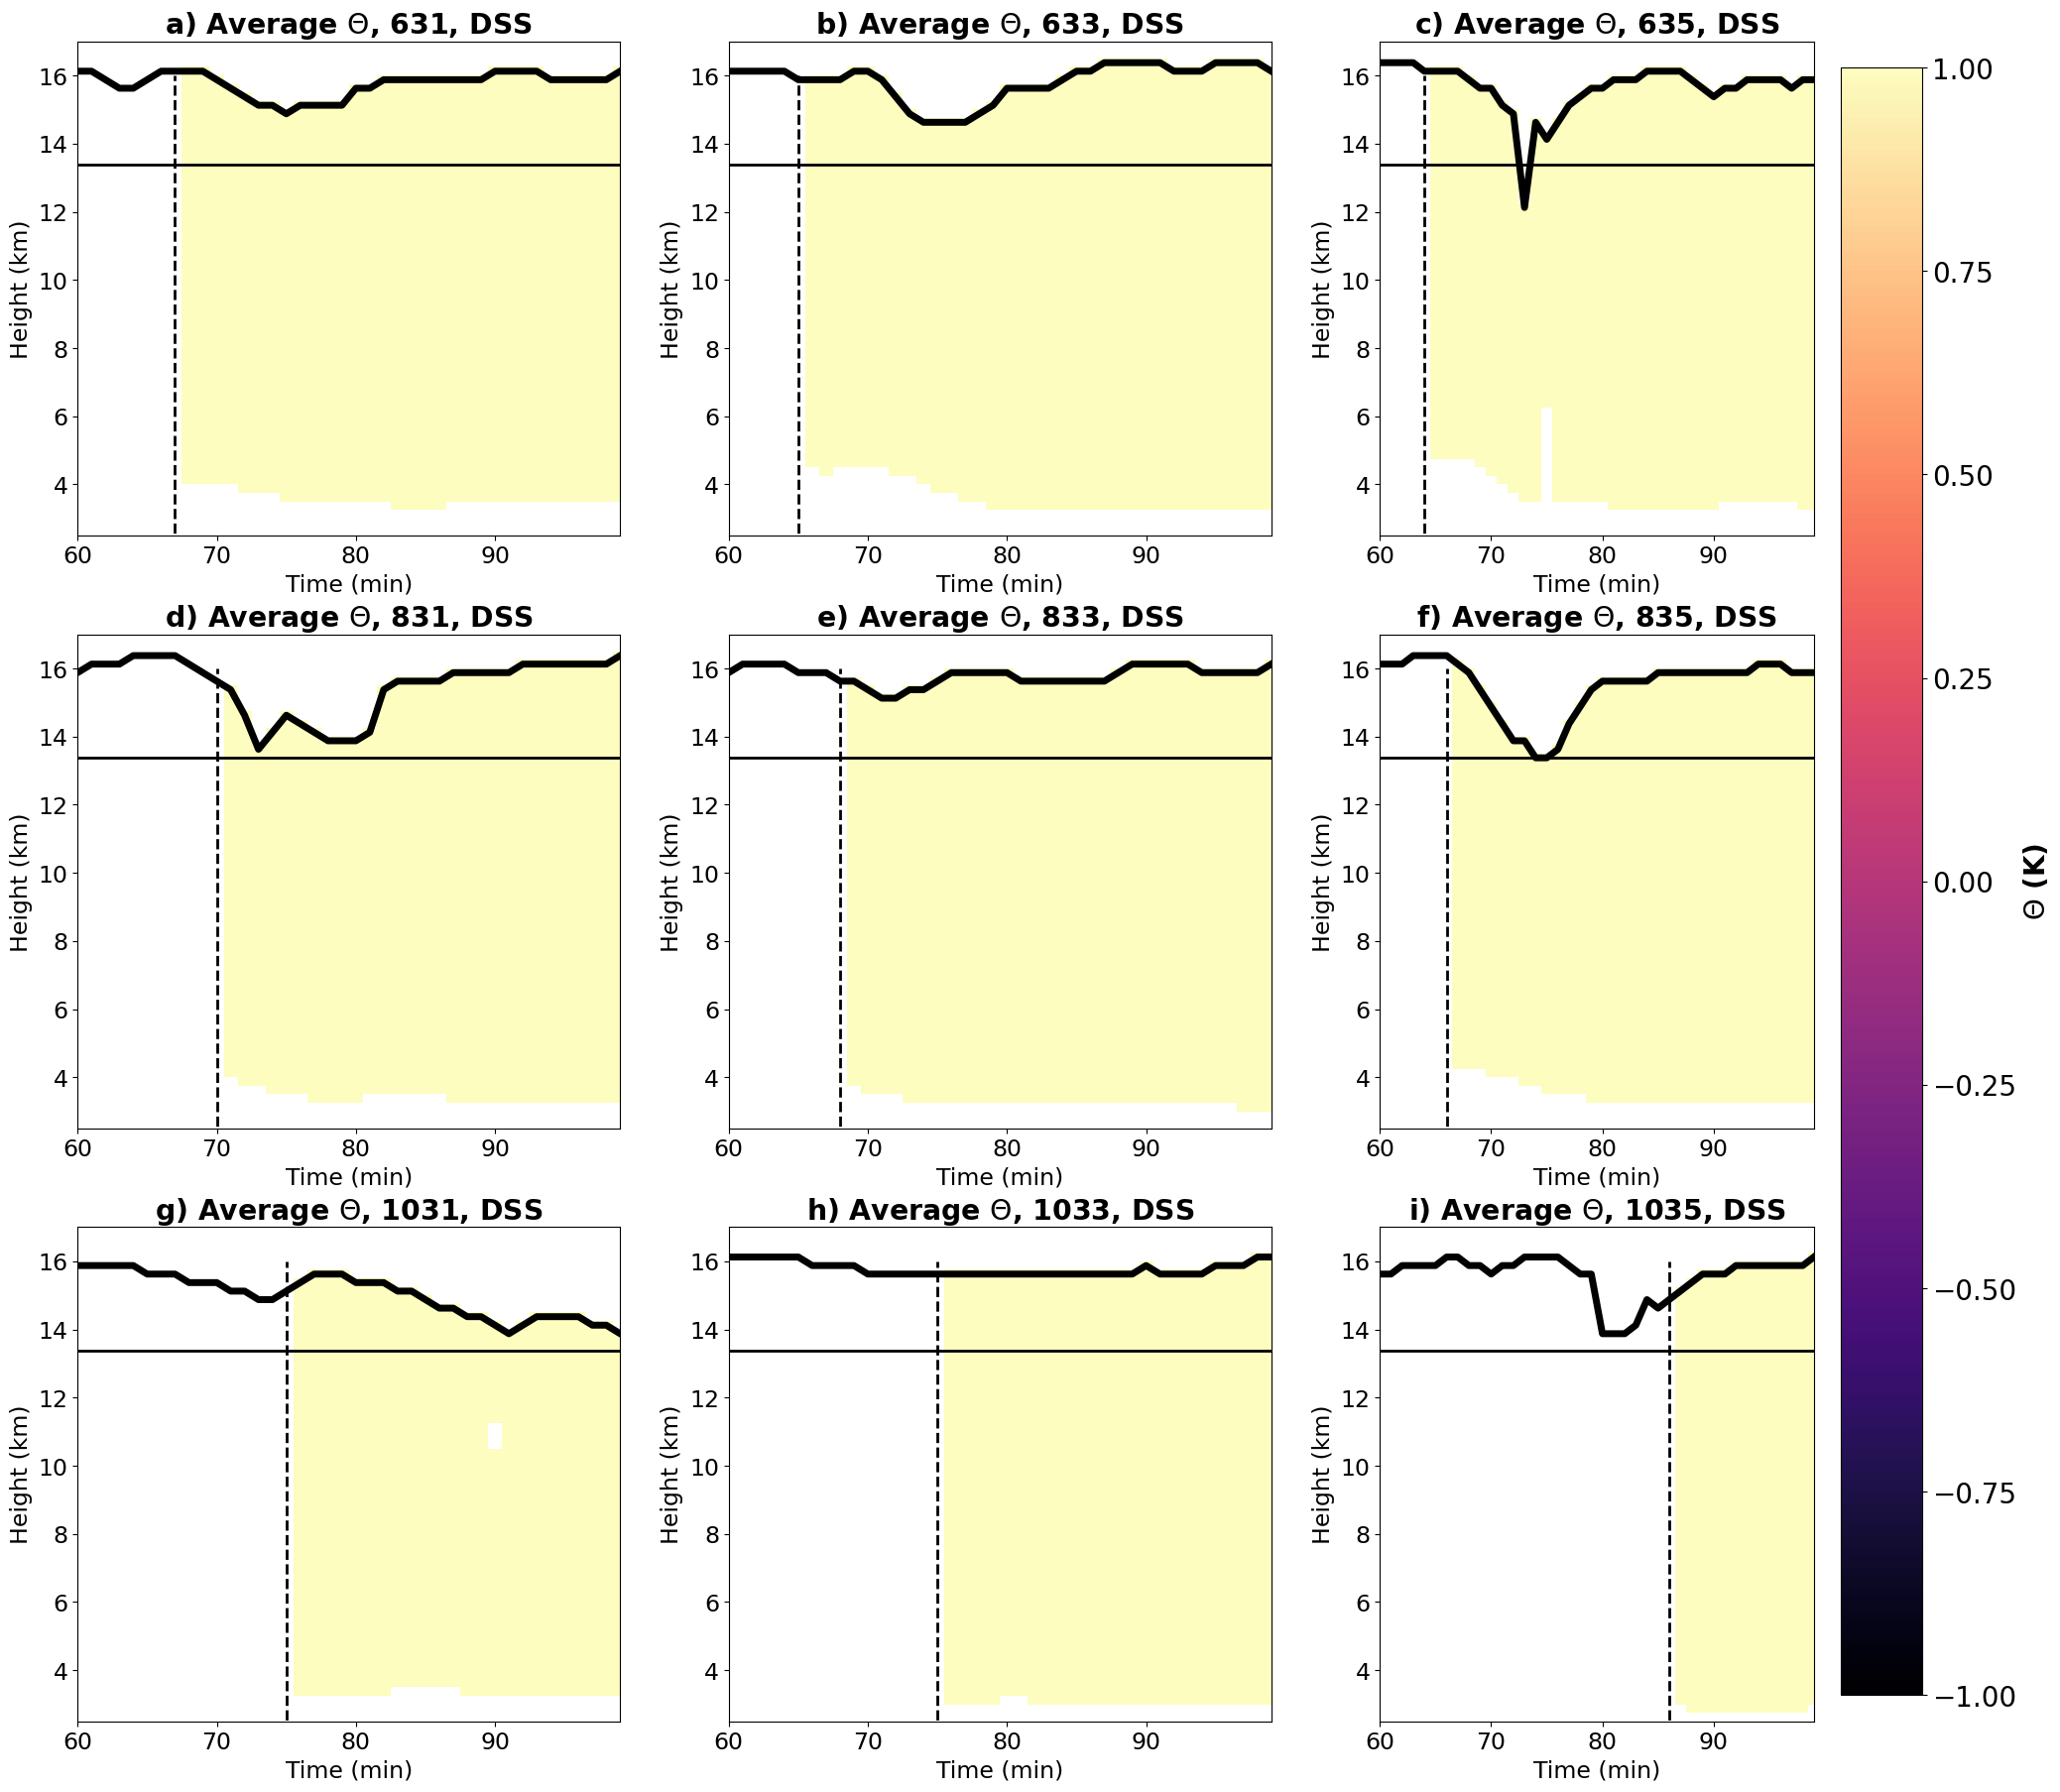

In [25]:
grid_plotting_function(['time_x', 'hght_x', 'corr_coef', 'wavg_over_polygon'])

# Let's understand how the median value of different characteristics change with height

In [41]:
#1. Let's examine temporal changes to the level of max Zvort median
#Let's get the height of the maximum average zvort at each time step

grouped_zvort_631_max = no_dupes_631.groupby('time_x')['zvavg_over_polygon'].idxmax()
height_631_max = no_dupes_631.loc[grouped_zvort_631_max]['hght_x']
grouped_zvort_633_max = no_dupes_633.groupby('time_x')['zvavg_over_polygon'].idxmax()
height_633_max = no_dupes_633.loc[grouped_zvort_633_max]['hght_x']
grouped_zvort_635_max = no_dupes_635.groupby('time_x')['zvavg_over_polygon'].idxmax()
height_635_max = no_dupes_635.loc[grouped_zvort_635_max]['hght_x']
grouped_zvort_831_max = no_dupes_831.groupby('time_x')['zvavg_over_polygon'].idxmax()
height_831_max = no_dupes_831.loc[grouped_zvort_831_max]['hght_x']
grouped_zvort_833_max = no_dupes_833.groupby('time_x')['zvavg_over_polygon'].idxmax()
height_833_max = no_dupes_833.loc[grouped_zvort_833_max]['hght_x']
grouped_zvort_835_max = no_dupes_835.groupby('time_x')['zvavg_over_polygon'].idxmax()
height_835_max = no_dupes_835.loc[grouped_zvort_835_max]['hght_x']
grouped_zvort_1031_max = no_dupes_1031.groupby('time_x')['zvavg_over_polygon'].idxmax()
height_1031_max = no_dupes_1031.loc[grouped_zvort_1031_max]['hght_x']
grouped_zvort_1033_max = no_dupes_1033.groupby('time_x')['zvavg_over_polygon'].idxmax()
height_1033_max = no_dupes_1033.loc[grouped_zvort_1033_max]['hght_x']
grouped_zvort_1035_max = no_dupes_1035.groupby('time_x')['zvavg_over_polygon'].idxmax()
height_1035_max = no_dupes_1035.loc[grouped_zvort_1035_max]['hght_x']

grouped_zvort_631_min = no_dupes_631.groupby('time_x')['zvavg_over_polygon'].idxmax()
height_631_min = no_dupes_631.loc[grouped_zvort_631_min]['hght_x']
grouped_zvort_633_min = no_dupes_633.groupby('time_x')['zvavg_over_polygon'].idxmax()
height_633_min = no_dupes_633.loc[grouped_zvort_633_min]['hght_x']
grouped_zvort_635_min = no_dupes_635.groupby('time_x')['zvavg_over_polygon'].idxmax()
height_635_min = no_dupes_635.loc[grouped_zvort_635_min]['hght_x']
grouped_zvort_831_min = no_dupes_831.groupby('time_x')['zvavg_over_polygon'].idxmax()
height_831_min = no_dupes_831.loc[grouped_zvort_831_min]['hght_x']
grouped_zvort_833_min = no_dupes_833.groupby('time_x')['zvavg_over_polygon'].idxmax()
height_833_min = no_dupes_833.loc[grouped_zvort_833_min]['hght_x']
grouped_zvort_835_min = no_dupes_835.groupby('time_x')['zvavg_over_polygon'].idxmax()
height_835_min = no_dupes_835.loc[grouped_zvort_835_min]['hght_x']
grouped_zvort_1031_min = no_dupes_1031.groupby('time_x')['zvavg_over_polygon'].idxmax()
height_1031_min = no_dupes_1031.loc[grouped_zvort_1031_min]['hght_x']
grouped_zvort_1033_min = no_dupes_1033.groupby('time_x')['zvavg_over_polygon'].idxmax()
height_1033_min = no_dupes_1033.loc[grouped_zvort_1033_min]['hght_x']
grouped_zvort_1035_min = no_dupes_1035.groupby('time_x')['zvavg_over_polygon'].idxmax()
height_1035_min = no_dupes_1035.loc[grouped_zvort_1035_min]['hght_x']


grouped_time_631 = no_dupes_631.groupby('time_x')
grouped_time_633 = no_dupes_633.groupby('time_x')
grouped_time_635 = no_dupes_635.groupby('time_x')
grouped_time_831 = no_dupes_831.groupby('time_x')
grouped_time_833 = no_dupes_833.groupby('time_x')
grouped_time_835 = no_dupes_835.groupby('time_x')
grouped_time_1031 = no_dupes_1031.groupby('time_x')
grouped_time_1033 = no_dupes_1033.groupby('time_x')
grouped_time_1035 = no_dupes_1035.groupby('time_x')

grouped_hght_631 = no_dupes_631.groupby('hght_x')
grouped_hght_633 = no_dupes_633.groupby('hght_x')
grouped_hght_635 = no_dupes_635.groupby('hght_x')
grouped_hght_831 = no_dupes_831.groupby('hght_x')
grouped_hght_833 = no_dupes_833.groupby('hght_x')
grouped_hght_835 = no_dupes_835.groupby('hght_x')
grouped_hght_1031 = no_dupes_1031.groupby('hght_x')
grouped_hght_1033 = no_dupes_1033.groupby('hght_x')
grouped_hght_1035 = no_dupes_1035.groupby('hght_x')

In [42]:
zv_filt_631 = no_dupes_631[no_dupes_631.pprtavg_over_polygon > 0.01]
zv_filt_633 = no_dupes_633[no_dupes_633.pprtavg_over_polygon > 0.01]
zv_filt_635 = no_dupes_635[no_dupes_635.pprtavg_over_polygon > 0.01]

zv_filt_831 = no_dupes_831[no_dupes_831.pprtavg_over_polygon > 0.01]
zv_filt_833 = no_dupes_833[no_dupes_833.pprtavg_over_polygon > 0.01]
zv_filt_835 = no_dupes_835[no_dupes_835.pprtavg_over_polygon > 0.01]

zv_filt_1031 = no_dupes_1031[no_dupes_1031.pprtavg_over_polygon > 0.01]
zv_filt_1033 = no_dupes_1033[no_dupes_1033.pprtavg_over_polygon > 0.01]
zv_filt_1035 = no_dupes_1035[no_dupes_1035.pprtavg_over_polygon > 0.01]

In [43]:
#Let's create a height diagram of all of the model runs with Zeta

zeta_631_max = grouped_hght_631.max()['zvavg_over_polygon']
zeta_633_max = grouped_hght_633.max()['zvavg_over_polygon']
zeta_635_max = grouped_hght_635.max()['zvavg_over_polygon']

zeta_831_max = grouped_hght_831.max()['zvavg_over_polygon']
zeta_833_max = grouped_hght_833.max()['zvavg_over_polygon']
zeta_835_max = grouped_hght_835.max()['zvavg_over_polygon']

zeta_1031_max = grouped_hght_1031.max()['zvavg_over_polygon']
zeta_1033_max = grouped_hght_1033.max()['zvavg_over_polygon']
zeta_1035_max = grouped_hght_1035.max()['zvavg_over_polygon']

#Let's create a height diagram of all of the model runs with Zeta

zeta_631_min = grouped_hght_631.min()['zvavg_over_polygon']
zeta_633_min = grouped_hght_633.min()['zvavg_over_polygon']
zeta_635_min = grouped_hght_635.min()['zvavg_over_polygon']

zeta_831_min = grouped_hght_831.min()['zvavg_over_polygon']
zeta_833_min = grouped_hght_833.min()['zvavg_over_polygon']
zeta_835_min = grouped_hght_835.min()['zvavg_over_polygon']

zeta_1031_min = grouped_hght_1031.min()['zvavg_over_polygon']
zeta_1033_min = grouped_hght_1033.min()['zvavg_over_polygon']
zeta_1035_min = grouped_hght_1035.min()['zvavg_over_polygon']

#Let's create a height diagram of all of the model runs with Zeta

zeta_631_median = grouped_hght_631.median()['zvavg_over_polygon']
zeta_633_median = grouped_hght_633.median()['zvavg_over_polygon']
zeta_635_median = grouped_hght_635.median()['zvavg_over_polygon']

zeta_831_median = grouped_hght_831.median()['zvavg_over_polygon']
zeta_833_median = grouped_hght_833.median()['zvavg_over_polygon']
zeta_835_median = grouped_hght_835.median()['zvavg_over_polygon']

zeta_1031_median = grouped_hght_1031.median()['zvavg_over_polygon']
zeta_1033_median = grouped_hght_1033.median()['zvavg_over_polygon']
zeta_1035_median = grouped_hght_1035.median()['zvavg_over_polygon']

In [44]:
#Let's find the level of maximum vorticity within the troposphere
zeta_631_max_trop = zeta_631_max[zeta_631_max.index < 8]
zeta_633_max_trop = zeta_633_max[zeta_633_max.index < 8]
zeta_635_max_trop = zeta_635_max[zeta_635_max.index < 8]

zeta_831_max_trop = zeta_831_max[zeta_831_max.index < 8]
zeta_833_max_trop = zeta_833_max[zeta_833_max.index < 8]
zeta_835_max_trop = zeta_835_max[zeta_835_max.index < 8]

zeta_1031_max_trop = zeta_1031_max[zeta_1031_max.index < 8]
zeta_1033_max_trop = zeta_1033_max[zeta_1033_max.index < 8]
zeta_1035_max_trop = zeta_1035_max[zeta_1035_max.index < 8]

zeta_631_min_trop = zeta_631_min[zeta_631_min.index < 8]
zeta_633_min_trop = zeta_633_min[zeta_633_min.index < 8]
zeta_635_min_trop = zeta_635_min[zeta_635_min.index < 8]

zeta_831_min_trop = zeta_831_min[zeta_831_min.index < 8]
zeta_833_min_trop = zeta_833_min[zeta_833_min.index < 8]
zeta_835_min_trop = zeta_835_min[zeta_835_min.index < 8]

zeta_1031_min_trop = zeta_1031_min[zeta_1031_min.index < 8]
zeta_1033_min_trop = zeta_1033_min[zeta_1033_min.index < 8]
zeta_1035_min_trop = zeta_1035_min[zeta_1035_min.index < 8]

zeta_631_median_trop = zeta_631_median[zeta_631_median.index < 8]
zeta_633_median_trop = zeta_633_median[zeta_633_median.index < 8]
zeta_635_median_trop = zeta_635_median[zeta_635_median.index < 8]

zeta_831_median_trop = zeta_831_median[zeta_831_median.index < 8]
zeta_833_median_trop = zeta_833_median[zeta_833_median.index < 8]
zeta_835_median_trop = zeta_835_median[zeta_835_median.index < 8]

zeta_1031_median_trop = zeta_1031_median[zeta_1031_median.index < 8]
zeta_1033_median_trop = zeta_1033_median[zeta_1033_median.index < 8]
zeta_1035_median_trop = zeta_1035_median[zeta_1035_median.index < 8]

In [45]:
#Calculate the average between the min, median and max, find that height and add it to the plot
avg_631 = np.mean([zeta_631_max_trop, zeta_631_median_trop, zeta_631_min_trop])
avg_631_hght = np.mean([zeta_631_median_trop.idxmax(axis = 0, skipna=True), zeta_631_min_trop.idxmax(axis = 0, skipna=True),\
                        zeta_631_max_trop.idxmax(axis = 0, skipna=True)])
avg_633 = np.mean([zeta_633_median_trop, zeta_633_max_trop, zeta_633_min_trop])
avg_633_hght = np.mean([zeta_633_median_trop.idxmax(axis = 0, skipna=True), zeta_633_max_trop.idxmax(axis = 0, skipna=True),\
                        zeta_633_min_trop.idxmax(axis = 0, skipna=True)])
avg_635 = np.mean([zeta_635_median_trop, zeta_635_min_trop, zeta_635_max_trop])
avg_635_hght = np.mean([zeta_635_median_trop.idxmax(axis = 0, skipna=True), zeta_635_max_trop.idxmax(axis = 0, skipna=True),\
                        zeta_635_min_trop.idxmax(axis = 0, skipna=True)])
#Calculate the average between the min, median and max, find that height and add it to the plot
avg_831 = np.mean([zeta_831_max_trop, zeta_831_median_trop, zeta_831_min_trop])
avg_831_hght = np.mean([zeta_831_median_trop.idxmax(axis = 0, skipna=True), zeta_831_min_trop.idxmax(axis = 0, skipna=True),\
                        zeta_831_max_trop.idxmax(axis = 0, skipna=True)])
avg_833 = np.mean([zeta_833_median_trop, zeta_833_max_trop, zeta_833_min_trop])
avg_833_hght = np.mean([zeta_833_median_trop.idxmax(axis = 0, skipna=True), zeta_833_max_trop.idxmax(axis = 0, skipna=True),\
                        zeta_833_min_trop.idxmax(axis = 0, skipna=True)])
avg_835 = np.mean([zeta_835_median_trop, zeta_835_min_trop, zeta_835_max_trop])
avg_835_hght = np.mean([zeta_835_median_trop.idxmax(axis = 0, skipna=True), zeta_835_max_trop.idxmax(axis = 0, skipna=True),\
                        zeta_835_min_trop.idxmax(axis = 0, skipna=True)])
#Calculate the average between the min, median and max, find that height and add it to the plot
avg_1031 = np.mean([zeta_1031_max_trop, zeta_1031_median_trop, zeta_1031_min_trop])
avg_1031_hght = np.mean([zeta_1031_median_trop.idxmax(axis = 0, skipna=True), zeta_1031_min_trop.idxmax(axis = 0, skipna=True),\
                        zeta_1031_max_trop.idxmax(axis = 0, skipna=True)])
avg_1033 = np.mean([zeta_1033_median_trop, zeta_1033_max_trop, zeta_1033_min_trop])
avg_1033_hght = np.mean([zeta_1033_median_trop.idxmax(axis = 0, skipna=True), zeta_1033_max_trop.idxmax(axis = 0, skipna=True),\
                        zeta_1033_min_trop.idxmax(axis = 0, skipna=True)])
avg_1035 = np.mean([zeta_1035_median_trop, zeta_1035_min_trop, zeta_1035_max_trop])
avg_1035_hght = np.mean([zeta_1035_median_trop.idxmax(axis = 0, skipna=True), zeta_1035_max_trop.idxmax(axis = 0, skipna=True),\
                        zeta_1035_min_trop.idxmax(axis = 0, skipna=True)])

Text(0.5, 0.97, 'Updraft Core Average $\\zeta$')

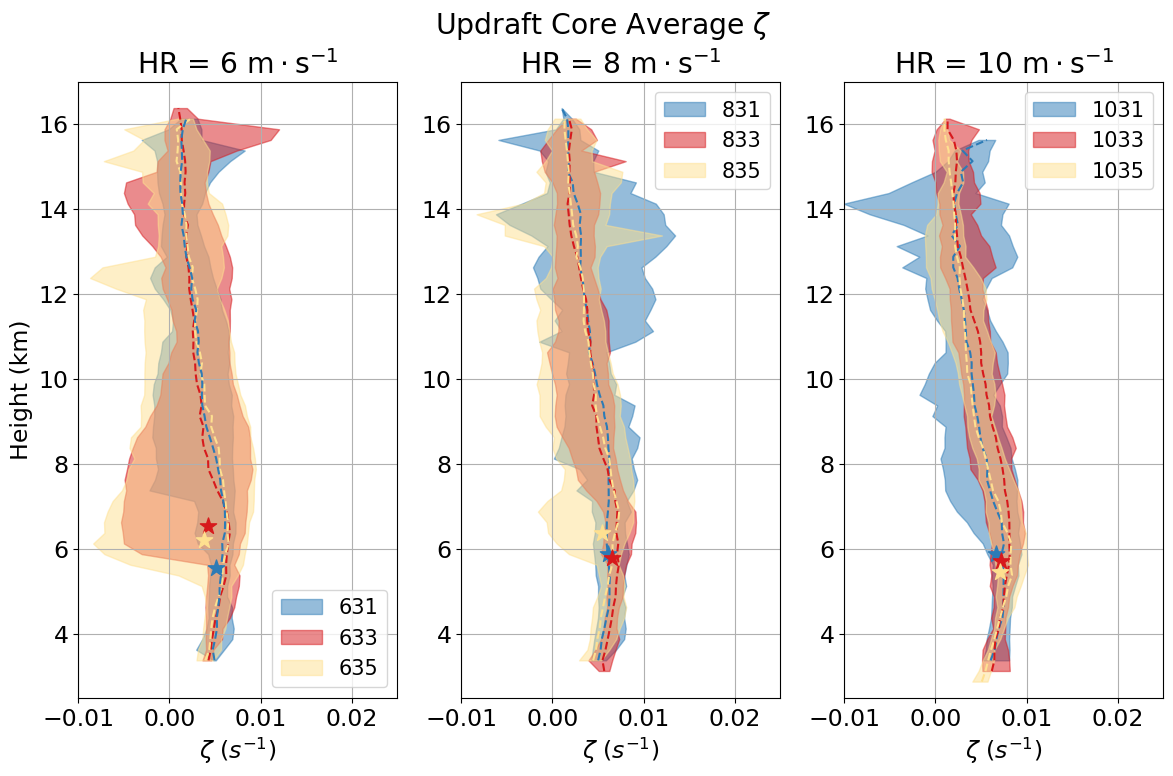

In [50]:
fig, axes = plt.subplots(nrows = 1, ncols = 3, figsize = (14, 8))
for ax in axes.flat:
    ax.grid(True)
    #(m$\cdot$$s^{-1}$)
    ax.set_xlabel(r'$\zeta$ ($s^{-1}$)')
axes[0].fill_betweenx(zeta_631_max.index, zeta_631_min, zeta_631_max, color = '#2c7bb6', alpha = 0.5, label = '631',\
                      zorder = 1)
axes[0].plot(zeta_631_median, zeta_631_median.index, color = '#2c7bb6', ls = '--', zorder = 5)
axes[0].scatter(avg_631, avg_631_hght, c = '#2c7bb6', marker = "*", s = 150, zorder = 10)
#axes[0].hlines(zeta_631_median_trop.idxmax(axis = 0, skipna=True), -200, 200, color = '#2c7bb6')
axes[0].fill_betweenx(zeta_633_max.index, zeta_633_min, zeta_633_max, color = '#d7191c', alpha = 0.5, label = '633',\
                      zorder = 1)
axes[0].plot(zeta_633_median, zeta_633_median.index,  ls = '--', color = '#d7191c')
axes[0].scatter(avg_633, avg_633_hght, c = '#d7191c', marker = "*", s = 150, zorder = 10)
#axes[0].hlines(zeta_633_median_trop.idxmax(axis = 0, skipna=True), -200, 200, color = '#d7191c')
axes[0].fill_betweenx(zeta_635_max.index, zeta_635_min, zeta_635_max, color = '#fee090', alpha = 0.5, label = '635')
axes[0].plot(zeta_635_median, zeta_635_median.index,  ls = '--', color = '#fee090')
axes[0].scatter(avg_635, avg_635_hght, c = '#fee090', marker = "*", s = 150, zorder = 10)
#axes[0].hlines(zeta_635_median_trop.idxmax(axis = 0, skipna=True), -200, 200, color = '#fee090')
axes[0].set_title(r'HR = 6 $\mathrm{m\cdot s^{-1}}$')
axes[0].set_ylabel('Height (km)')
axes[0].legend(loc = 'best', fontsize = 15)

axes[1].fill_betweenx(zeta_831_max.index, zeta_831_min, zeta_831_max, color = '#2c7bb6', alpha = 0.5, label = '831')
axes[1].plot(zeta_831_median, zeta_831_median.index, color = '#2c7bb6', ls = '--')
axes[1].scatter(avg_831, avg_831_hght, c = '#2c7bb6', marker = "*", s = 150, zorder = 10)
#axes[1].hlines(zeta_831_median_trop.idxmax(axis = 0, skipna=True), -200, 200, color = '#2c7bb6')
axes[1].fill_betweenx(zeta_833_max.index, zeta_833_min, zeta_833_max, color = '#d7191c', alpha = 0.5, label = '833')
axes[1].plot(zeta_833_median, zeta_833_median.index,  ls = '--', color = '#d7191c')
axes[1].scatter(avg_833, avg_833_hght, c = '#d7191c', marker = "*", s = 150, zorder = 10)
#axes[1].hlines(zeta_833_median_trop.idxmax(axis = 0, skipna=True), -200, 200, color = '#d7191c')
axes[1].fill_betweenx(zeta_835_max.index, zeta_835_min, zeta_835_max, color = '#fee090', alpha = 0.5, label = '835')
axes[1].plot(zeta_835_median, zeta_835_median.index,  ls = '--', color = '#fee090')
axes[1].scatter(avg_835, avg_835_hght, c = '#fee090', marker = "*", s = 150, zorder = 10)
#axes[1].hlines(zeta_835_median_trop.idxmax(axis = 0, skipna=True), -200, 200, color = '#fee090')
axes[1].set_title(r'HR = 8 $\mathrm{m\cdot s^{-1}}$')
axes[1].legend(loc = 'best', fontsize = 15)

axes[2].fill_betweenx(zeta_1031_max.index, zeta_1031_min, zeta_1031_max, color = '#2c7bb6', alpha = 0.5, label = '1031')
axes[2].plot(zeta_1031_median, zeta_1031_median.index, color = '#2c7bb6', ls = '--')
axes[2].scatter(avg_1031, avg_1031_hght, c = '#2c7bb6', marker = "*", s = 150, zorder = 10)
#axes[2].hlines(zeta_1031_median_trop.idxmax(axis = 0, skipna=True), -200, 200, color = '#2c7bb6')
axes[2].fill_betweenx(zeta_1033_max.index, zeta_1033_min, zeta_1033_max, color = '#d7191c', alpha = 0.5, label = '1033')
axes[2].plot(zeta_1033_median, zeta_1033_median.index,  ls = '--', color = '#d7191c')
axes[2].scatter(avg_1033, avg_1033_hght, c = '#d7191c', marker = "*", s = 150, zorder = 10)
#axes[2].hlines(zeta_1033_median_trop.idxmax(axis = 0, skipna=True), -200, 200, color = '#d7191c')
axes[2].fill_betweenx(zeta_1035_max.index, zeta_1035_min, zeta_1035_max, color = '#fee090', alpha = 0.5, label = '1035')
axes[2].plot(zeta_1035_median, zeta_1035_median.index,  ls = '--', color = '#fee090')
axes[2].scatter(avg_1035, avg_1035_hght, c = '#fee090', marker = "*", s = 150, zorder = 10)
#axes[2].hlines(zeta_1035_median_trop.idxmax(axis = 0, skipna=True), -200, 200, color = '#fee090')
axes[2].legend(loc = 'best', fontsize = 15)
axes[2].set_title(r'HR = 10 $\mathrm{m\cdot s^{-1}}$')

plt.setp((axes), xlim=(-0.01, 0.025), ylim=(2.5, 17))
plt.suptitle(r'Updraft Core Average $\zeta$', y = 0.97)

Text(0.5, 0.93, 'Updraft Core Average $P^\\prime_{b}$')

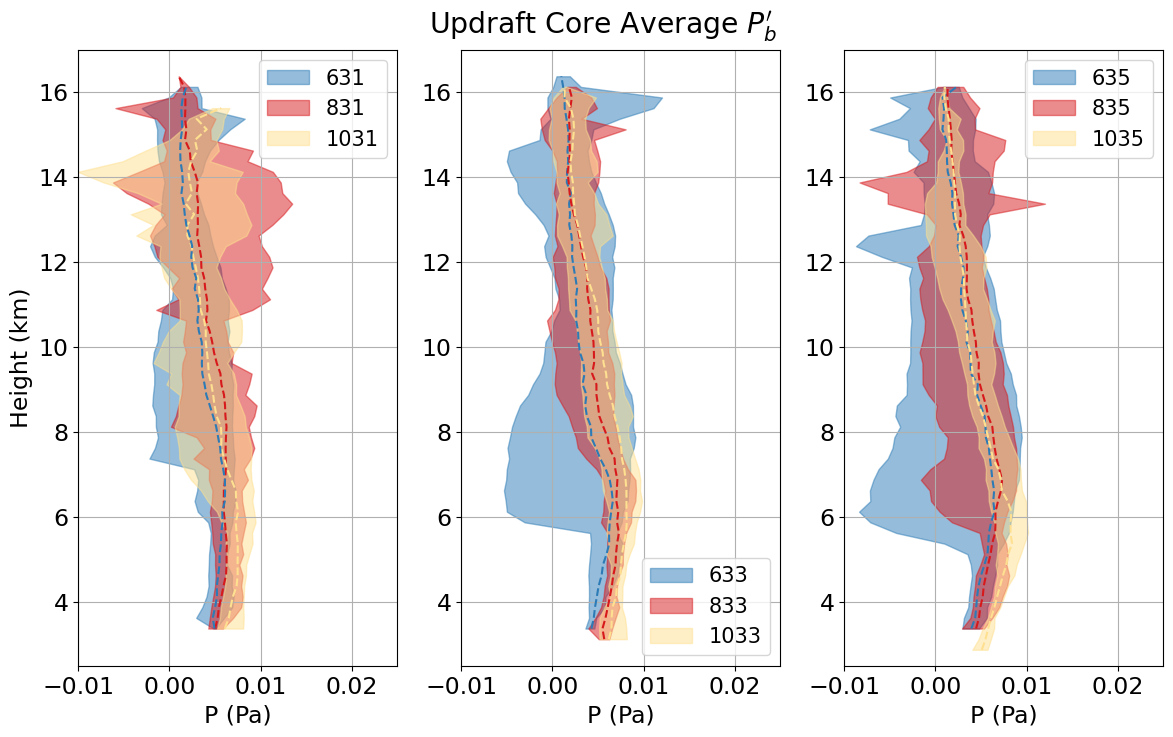

In [19]:
fig, axes = plt.subplots(nrows = 1, ncols = 3, figsize = (14, 8))
for ax in axes.flat:
    ax.grid(True)
    #(m$\cdot$$s^{-1}$)
    # $\zeta$ ($s^{-1}$)
    ax.set_xlabel(r'P (Pa)')
axes[0].fill_betweenx(zeta_631_max.index, zeta_631_min, zeta_631_max, color = '#2c7bb6', alpha = 0.5, label = '631',\
                      zorder = 1)
axes[0].plot(zeta_631_median, zeta_631_median.index, color = '#2c7bb6', ls = '--', zorder = 5)
#axes[0].scatter(min(zeta_631_median_trop) ,zeta_631_median_trop.idxmax(axis = 0, skipna=True), c = '#2c7bb6', marker = "*",
 #               s = 150, zorder = 10)
#axes[0].hlines(zeta_631_median_trop.idxmax(axis = 0, skipna=True), -200, 200, color = '#2c7bb6')
axes[0].fill_betweenx(zeta_831_max.index, zeta_831_min, zeta_831_max, color = '#d7191c', alpha = 0.5, label = '831',\
                      zorder = 1)
axes[0].plot(zeta_831_median, zeta_831_median.index,  ls = '--', color = '#d7191c')
#axes[0].scatter(min(zeta_831_median_trop) ,zeta_831_median_trop.idxmax(axis = 0, skipna=True), c = '#d7191c', marker = "*",
 #               s = 150, zorder = 10)
#axes[0].hlines(zeta_831_median_trop.idxmax(axis = 0, skipna=True), -200, 200, color = '#d7191c')
axes[0].fill_betweenx(zeta_1031_max.index, zeta_1031_min, zeta_1031_max, color = '#fee090', alpha = 0.5, label = '1031')
axes[0].plot(zeta_1031_median, zeta_1031_median.index,  ls = '--', color = '#fee090')
#axes[0].scatter(min(zeta_1031_median_trop) ,zeta_1031_median_trop.idxmax(axis = 0, skipna=True), c = '#fee090', marker = "*",
 #               s = 150, zorder = 10)
#axes[0].hlines(zeta_1031_median_trop.idxmax(axis = 0, skipna=True), -200, 200, color = '#fee090')
axes[0].set_ylabel('Height (km)')
axes[0].legend(loc = 'best', fontsize = 15)

axes[1].fill_betweenx(zeta_633_max.index, zeta_633_min, zeta_633_max, color = '#2c7bb6', alpha = 0.5, label = '633')
axes[1].plot(zeta_633_median, zeta_633_median.index, color = '#2c7bb6', ls = '--')
#axes[1].scatter(min(zeta_633_median_trop) ,zeta_633_median_trop.idxmax(axis = 0, skipna=True), c = '#2c7bb6', marker = "*",
 #               s = 150, zorder = 10)
#axes[1].hlines(zeta_633_median_trop.idxmax(axis = 0, skipna=True), -200, 200, color = '#2c7bb6')
axes[1].fill_betweenx(zeta_833_max.index, zeta_833_min, zeta_833_max, color = '#d7191c', alpha = 0.5, label = '833')
axes[1].plot(zeta_833_median, zeta_833_median.index,  ls = '--', color = '#d7191c')
#axes[1].scatter(min(zeta_833_median_trop) ,zeta_833_median_trop.idxmax(axis = 0, skipna=True), c = '#d7191c', marker = "*",
 #               s = 150, zorder = 10)
#axes[1].hlines(zeta_833_median_trop.idxmax(axis = 0, skipna=True), -200, 200, color = '#d7191c')
axes[1].fill_betweenx(zeta_1033_max.index, zeta_1033_min, zeta_1033_max, color = '#fee090', alpha = 0.5, label = '1033')
axes[1].plot(zeta_1033_median, zeta_1033_median.index,  ls = '--', color = '#fee090')
#axes[1].scatter(min(zeta_1033_median_trop), zeta_1033_median_trop.idxmax(axis = 0, skipna=True), c = '#fee090', marker = "*",
 #               s = 150, zorder = 10)
#axes[1].hlines(zeta_1033_median_trop.idxmax(axis = 0, skipna=True), -200, 200, color = '#fee090')
axes[1].legend(loc = 'best', fontsize = 15)

axes[2].fill_betweenx(zeta_635_max.index, zeta_635_min, zeta_635_max, color = '#2c7bb6', alpha = 0.5, label = '635')
axes[2].plot(zeta_635_median, zeta_635_median.index, color = '#2c7bb6', ls = '--')
#axes[2].scatter(min(zeta_635_median_trop) ,zeta_635_median_trop.idxmax(axis = 0, skipna=True), c = '#2c7bb6', marker = "*",
 #               s = 150, zorder = 10)
#axes[2].hlines(zeta_635_median_trop.idxmax(axis = 0, skipna=True), -200, 200, color = '#2c7bb6')
axes[2].fill_betweenx(zeta_835_max.index, zeta_835_min, zeta_835_max, color = '#d7191c', alpha = 0.5, label = '835')
axes[2].plot(zeta_835_median, zeta_835_median.index,  ls = '--', color = '#d7191c')
#axes[2].scatter(min(zeta_835_median_trop) ,zeta_835_median_trop.idxmax(axis = 0, skipna=True), c = '#d7191c', marker = "*",
 #               s = 150, zorder = 10)
#axes[2].hlines(zeta_835_median_trop.idxmax(axis = 0, skipna=True), -200, 200, color = '#d7191c')
axes[2].fill_betweenx(zeta_1035_max.index, zeta_1035_min, zeta_1035_max, color = '#fee090', alpha = 0.5, label = '1035')
axes[2].plot(zeta_1035_median, zeta_1035_median.index,  ls = '--', color = '#fee090')
#axes[2].scatter(min(zeta_1035_median_trop), zeta_1035_median_trop.idxmax(axis = 0, skipna=True), c = '#fee090', marker = "*",
 #               s = 150, zorder = 10)
#axes[2].hlines(zeta_1035_median_trop.idxmax(axis = 0, skipna=True), -200, 200, color = '#fee090')
axes[2].legend(loc = 'best', fontsize = 15)

plt.setp((axes),xlim=(-.01, .025), ylim=(2.5, 17))
# $\zeta$
plt.suptitle(r'Updraft Core Average $P^\prime_{b}$', y = 0.93)

In [20]:
avg6 = np.mean(np.array([min(zeta_631_median_trop), min(zeta_633_median_trop), min(zeta_635_median_trop),\
                min(zeta_631_max_trop), min(zeta_633_max_trop), min(zeta_635_max_trop), \
                min(zeta_631_min_trop), min(zeta_633_min_trop), min(zeta_635_min_trop)]))
hght6 = np.mean(np.array([zeta_631_median_trop.idxmin(axis = 0, skipna=True), zeta_633_median_trop.idxmin(axis = 0, skipna=True),\
    zeta_635_median_trop.idxmin(axis = 0, skipna=True), zeta_631_max_trop.idxmin(axis = 0, skipna=True), zeta_633_max_trop.idxmin(axis = 0, skipna=True),\
    zeta_635_max_trop.idxmin(axis = 0, skipna=True), zeta_631_min_trop.idxmin(axis = 0, skipna=True), zeta_633_min_trop.idxmin(axis = 0, skipna=True),\
    zeta_635_min_trop.idxmin(axis = 0, skipna=True)]))

print(avg6/100, hght6)

-7.408667071205332e-06 14.12500061111111


In [71]:
#Calculate the slope of the lines before and after the critical level
before_631_max = zeta_631_max_trop[:zeta_631_max_trop.idxmin(axis = 0, skipna=True)]
after_631_max = zeta_631_max_trop[zeta_631_max_trop.idxmin(axis = 0, skipna=True):]
before_631_median = zeta_631_median_trop[:zeta_631_median_trop.idxmin(axis = 0, skipna=True)]
after_631_median = zeta_631_median_trop[zeta_631_max_trop.idxmin(axis = 0, skipna=True):] 
before_631_min = zeta_631_min_trop[:zeta_631_min_trop.idxmin(axis = 0, skipna=True)] 
after_631_min = zeta_631_min_trop[zeta_631_max_trop.idxmin(axis = 0, skipna=True):]
before_633_median = zeta_633_median_trop[:zeta_633_median_trop.idxmin(axis = 0, skipna=True)]
after_633_median = zeta_633_median_trop[zeta_633_median_trop.idxmin(axis = 0, skipna=True):]
before_633_max = zeta_633_max_trop[:zeta_633_max_trop.idxmin(axis = 0, skipna=True)] 
after_633_max = zeta_633_max_trop[zeta_633_max_trop.idxmin(axis = 0, skipna=True):] 
before_633_min = zeta_633_min_trop[:zeta_633_max_trop.idxmin(axis = 0, skipna=True)]  
after_633_min = zeta_633_max_trop[zeta_633_max_trop.idxmin(axis = 0, skipna=True):] 
before_635_median = zeta_635_median_trop[:zeta_635_median_trop.idxmin(axis = 0, skipna=True)]
after_635_median = zeta_635_median_trop[zeta_635_median_trop.idxmin(axis = 0, skipna=True):]
before_635_max = zeta_635_max_trop[:zeta_635_max_trop.idxmin(axis = 0, skipna=True)]
after_635_max = zeta_635_max_trop[zeta_635_max_trop.idxmin(axis = 0, skipna=True):]
before_635_min = zeta_635_min_trop[:zeta_635_min_trop.idxmin(axis = 0, skipna=True)] 
after_635_min = zeta_635_min_trop[zeta_635_min_trop.idxmin(axis = 0, skipna=True):] 

In [72]:
#Calculate the slope of each line
before_631_slope_min, *rest = linregress(before_631_min.values, before_631_min.index)
before_633_slope_min, *rest = linregress(before_633_min.values, before_633_min.index)
before_635_slope_min, *rest = linregress(before_635_min.values, before_635_min.index)
avg_before_slope_min = np.mean(np.array([before_631_slope_min, before_633_slope_min, before_635_slope_min]))
after_631_slope_min, *rest = linregress(after_631_min.values, after_631_min.index)
after_633_slope_min, *rest = linregress(after_633_min.values, after_633_min.index)
after_635_slope_min, *rest = linregress(after_635_min.values, after_635_min.index)
avg_after_slope_min = np.mean(np.array([after_631_slope_min, after_633_slope_min, after_635_slope_min]))

#Calculate the slope of each line
before_631_slope_median, *rest = linregress(before_631_median.values, before_631_median.index)
before_633_slope_median, *rest = linregress(before_633_median.values, before_633_median.index)
before_635_slope_median, *rest = linregress(before_635_median.values, before_635_median.index)
avg_before_slope_median = np.mean(np.array([before_631_slope_median, before_633_slope_median, before_635_slope_median]))
after_631_slope_median, *rest = linregress(after_631_median.values, after_631_median.index)
after_633_slope_median, *rest = linregress(after_633_median.values, after_633_median.index)
after_635_slope_median, *rest = linregress(after_635_median.values, after_635_median.index)
avg_after_slope_median = np.mean(np.array([after_631_slope_median, after_633_slope_median, after_635_slope_median]))
#Calculate the slope of each line
before_631_slope_max, *rest = linregress(before_631_max.values, before_631_max.index)
before_633_slope_max, *rest = linregress(before_633_max.values, before_633_max.index)
before_635_slope_max, *rest = linregress(before_635_max.values, before_635_max.index)
avg_before_slope_max = np.mean(np.array([before_631_slope_max, before_633_slope_max, before_635_slope_max]))
after_631_slope_max, *rest = linregress(after_631_max.values, after_631_max.index)
after_633_slope_max, *rest = linregress(after_633_max.values, after_633_max.index)
after_635_slope_max, *rest = linregress(after_635_max.values, after_635_max.index)
avg_after_slope_max = np.mean(np.array([after_631_slope_max, after_633_slope_max, after_635_slope_max]))

In [73]:
np.mean(np.array([avg_before_slope_min, avg_before_slope_max, avg_before_slope_median])), np.mean(np.array([avg_after_slope_max, avg_after_slope_median, avg_after_slope_median]))

(np.float64(-0.041128315211817416), np.float64(0.03810298879015356))